# STEER on synthetic bimodal Trifeatures dataset

STEER trains **one** model over a grid of preferences
`λ = (λ_R, λ_U₁, λ_U₂)` on the 2-simplex, and the operating
point is chosen per downstream task afterwards — no retraining.

Trifeatures is the right place to see this, because the generative factors are known:

| factor | role | classes |
|---|---|---|
| shape | **redundant** R — drawn in both views | 15 |
| deformation | **unique to M1** U₁ | 10 |
| texture | **unique to M2** U₂ | 10 |

Shape is drawn independently of deformation and texture, so I(U; R) ≈ 0 and the
three tasks genuinely compete.

### Packages install

In [ ]:
%pip install -q torch torchvision scikit-learn matplotlib numpy scipy pillow tqdm

### Loading and visualizing the data

`data/tri15_corr00` ships with the repository: 2 800 records, each rendered as an M1/M2
pair.

In [1]:
import json, os, pathlib, sys
import matplotlib.pyplot as plt
from PIL import Image

# Paths below are relative to the repository root; the kernel may start in notebooks/
ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / "pareto_ssl").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "pareto_ssl").is_dir():
    raise SystemExit("run this notebook from inside the repository")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("working directory:", ROOT)

DATA = pathlib.Path("data/tri15_corr00")
meta = json.load(open(DATA / "metadata.json"))

n_R  = len({m["R"]  for m in meta})
n_U1 = len({m["U1"] for m in meta})
n_U2 = len({m["U2"] for m in meta})
print(f"{len(meta)} records")
print(f"  R  shape       (redundant) : {n_R:>2} classes, chance {100/n_R:.1f}%")
print(f"  U1 deformation (M1 only)   : {n_U1:>2} classes, chance {100/n_U1:.1f}%")
print(f"  U2 texture     (M2 only)   : {n_U2:>2} classes, chance {100/n_U2:.1f}%")

working directory: /neurospin/dico/babdelghani/Runs/02_champollion_v1/Program
2800 records
  R  shape       (redundant) : 15 classes, chance 6.7%
  U1 deformation (M1 only)   : 10 classes, chance 10.0%
  U2 texture     (M2 only)   : 10 classes, chance 10.0%

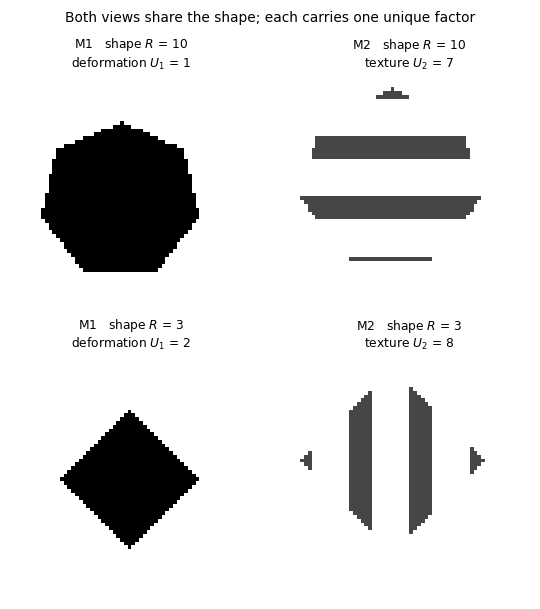

In [2]:
# Fetch 2 pairs of images (i.e. 2 data points)
fig, axes = plt.subplots(2, 2, figsize=(5.2, 5.6))
for row, rec in enumerate(meta[:2]):
    for ax, (key, mod, extra) in zip(
            axes[row], (("M1_path", "M1", f"deformation $U_1$ = {rec['U1']}"),
                        ("M2_path", "M2", f"texture $U_2$ = {rec['U2']}"))):
        ax.imshow(Image.open(DATA / rec[key])); ax.axis("off")
        ax.set_title(f"{mod}   shape $R$ = {rec['R']}\n{extra}", fontsize=8)
plt.suptitle("Both views share the shape; each carries one unique factor", fontsize=9)
plt.tight_layout(); plt.show()

### Fit STEER to bimodal Trifeatures

One run covers the whole simplex. Every minibatch is evaluated at all 15 preferences of
the side-5 grid and the losses are averaged before a single backward pass; the preferences
are annealed outward from the simplex centroid as training proceeds.

`EPOCHS = 100` is the reported setting. Drop it to 5 for a quick smoke run — the ordering
survives, the absolute numbers do not.

In [3]:
import torch
from pareto_ssl.benchmark import train_encoders

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS, SEED = 100, 42
# train_encoders saves flat into out_dir, so this is also the checkpoint dir
ENC = f"runs/steer_trifeature_e{EPOCHS}_s{SEED}"
print(f"torch {torch.__version__} | device: {DEVICE}")

train_encoders(
    method="simclr_simplex_enc_decomp_R",   # STEER, preference-conditioned encoder
    data_dir=str(DATA), out_dir=ENC, device=DEVICE,
    epochs=EPOCHS, lr=3e-4, batch_size=128,
    latent_dim=512, proj_dim=256,
    encoder_param="encoder",
    preference_schedule="annealed",         # centroid -> nominal preference over training
    annealing_temperature=1.0,
    lora_alpha=8, simplex_side=5,           # side-5 grid = 15 preferences
    dirichlet_alpha=0.3, pareto_solver="ls",
    lam_club=0.5,                           # CLUB weight reported for Trifeatures
    seed=SEED,
)

torch 2.6.0+cu124 | device: cuda
  simclr_simplex_enc_decomp_R: side=5 -> 15 prefs | M=15/step | anneal=power | enc_cond=True head_cond=False + 2 CLUB critics | lam_club=0.5 | readout=concat(3 x 256)
  epoch   1/100  loss=5.1319  crit=-0.0021  club_raw=+0.0013  clamp=0.17  cka(u,r)=0.9699  effrank_u=2.6  cos(r1,r2)=+0.071  [binding]
  epoch  10/100  loss=4.2895  crit=-0.0367  club_raw=+0.0433  clamp=0.19  cka(u,r)=0.7451  effrank_u=4.0  cos(r1,r2)=+0.086  [binding]
  epoch  20/100  loss=3.4272  crit=-0.0658  club_raw=+0.2486  clamp=0.06  cka(u,r)=0.4873  effrank_u=5.7  cos(r1,r2)=+0.701  [binding]
  epoch  30/100  loss=2.6607  crit=-0.0385  club_raw=+0.2153  clamp=0.01  cka(u,r)=0.4987  effrank_u=7.2  cos(r1,r2)=+0.709  [binding]
  epoch  40/100  loss=2.3788  crit=-0.2510  club_raw=+0.3292  clamp=0.01  cka(u,r)=0.4747  effrank_u=8.7  cos(r1,r2)=+0.695  [binding]
  epoch  50/100  loss=2.2983  crit=-0.3476  club_raw=+0.4153  clamp=0.01  cka(u,r)=0.4391  effrank_u=9.3  cos(r1,r2)=+0.700  

### Evaluate STEER across the preference simplex

A 1-shot linear probe is fitted at every preference, for each of the three tasks.

The representation is the `dim` read-out: a fixed 256-d budget split across the
`R / U₁ / U₂` blocks in proportion to λ, so total width is constant across the
simplex and only the allocation moves. Driving the library directly skips the CLI, whose
default this is, so `set_readout` has to say so.

In [4]:
from pareto_ssl.benchmark import probe_lambda_cond, set_readout, reset_readout_state

set_readout("dim")
reset_readout_state()

curve = probe_lambda_cond(
    enc_dir=ENC, data_dir=str(DATA), device=DEVICE,
    latent_dim=512, proj_dim=256, batch_size=128,
    k_shot=1,
)
prefs = [tuple(p) for p in curve["preferences"]]
print(f"\n{len(prefs)} preferences probed on 3 tasks")

  [simplex] probing (R,U1,U2)=(0.00,0.00,1.00)
    share: 0.2581
    unique1: 0.1101
    unique2: 0.3721
  [simplex] probing (R,U1,U2)=(0.00,0.25,0.75)
    share: 0.3269
    unique1: 0.1090
    unique2: 0.3497
  [simplex] probing (R,U1,U2)=(0.00,0.50,0.50)
    share: 0.4752
    unique1: 0.1688
    unique2: 0.3013
  [simplex] probing (R,U1,U2)=(0.00,0.75,0.25)
    share: 0.5551
    unique1: 0.2168
    unique2: 0.1786
  [simplex] probing (R,U1,U2)=(0.00,1.00,0.00)
    share: 0.5256
    unique1: 0.2274
    unique2: 0.0968
  [simplex] probing (R,U1,U2)=(0.25,0.00,0.75)
    share: 0.4355
    unique1: 0.0987
    unique2: 0.3631
  [simplex] probing (R,U1,U2)=(0.25,0.25,0.50)
    share: 0.6220
    unique1: 0.1334
    unique2: 0.2923
  [simplex] probing (R,U1,U2)=(0.25,0.50,0.25)
    share: 0.7734
    unique1: 0.1841
    unique2: 0.1880
  [simplex] probing (R,U1,U2)=(0.25,0.75,0.00)
    share: 0.7380
    unique1: 0.2341
    unique2: 0.0987
  [simplex] probing (R,U1,U2)=(0.50,0.00,0.50)
    shar

In [5]:
print(f"{'preference (R, U1, U2)':>24}{'shape R':>10}{'deform U1':>12}{'texture U2':>13}")
print("-" * 59)
for p, r, u1, u2 in zip(prefs, curve["share"], curve["unique1"], curve["unique2"]):
    lam = f"({p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f})"
    print(f"{lam:>24}{100*r:>9.1f}%{100*u1:>11.1f}%{100*u2:>12.1f}%")

  preference (R, U1, U2)   shape R   deform U1   texture U2
-----------------------------------------------------------
      (0.00, 0.00, 1.00)     25.8%       11.0%        37.2%
      (0.00, 0.25, 0.75)     32.7%       10.9%        35.0%
      (0.00, 0.50, 0.50)     47.5%       16.9%        30.1%
      (0.00, 0.75, 0.25)     55.5%       21.7%        17.9%
      (0.00, 1.00, 0.00)     52.6%       22.7%         9.7%
      (0.25, 0.00, 0.75)     43.5%        9.9%        36.3%
      (0.25, 0.25, 0.50)     62.2%       13.3%        29.2%
      (0.25, 0.50, 0.25)     77.3%       18.4%        18.8%
      (0.25, 0.75, 0.00)     73.8%       23.4%         9.9%
      (0.50, 0.00, 0.50)     68.5%       11.8%        28.2%
      (0.50, 0.25, 0.25)     93.7%       16.9%        15.7%
      (0.50, 0.50, 0.00)     95.4%       17.8%        11.5%
      (0.75, 0.00, 0.25)     98.6%       11.0%        14.2%
      (0.75, 0.25, 0.00)     99.7%       17.2%        13.0%
      (1.00, 0.00, 0.00)    100.0%      

In [6]:
import numpy as np

print("Best preference per task\n")
for name, key, n_cls in (("shape       R ", "share",   n_R),
                         ("deformation U1", "unique1", n_U1),
                         ("texture     U2", "unique2", n_U2)):
    i = int(np.argmax(curve[key]))
    lam = f"({prefs[i][0]:.2f}, {prefs[i][1]:.2f}, {prefs[i][2]:.2f})"
    print(f"  {name}  {100*curve[key][i]:5.1f}%  at lambda = {lam:<22}"
          f"chance {100/n_cls:.1f}%")

Best preference per task

  shape       R   100.0%  at lambda = (1.00, 0.00, 0.00)    chance 6.7%
  deformation U1   23.4%  at lambda = (0.25, 0.75, 0.00)    chance 10.0%
  texture     U2   37.2%  at lambda = (0.00, 0.00, 1.00)    chance 10.0%

Each task peaks at a **different** preference — which is the whole point: one pretrained
model, and the operating point chosen per task afterwards.

Shape and texture peak on the simplex vertices (1, 0, 0) and (0, 0, 1). Deformation peaks
just off its own vertex, at (0.25, 0.75, 0); the U₁ ridge is flat near that corner, so
which of those cells wins moves from seed to seed.

This is a **single seed**. Over seeds 42–46 the reported per-seed-best figures are shape
**99.98 ± 0.05**, deformation **29.16 ± 2.66** and texture **37.46 ± 3.96**, against chance
of 6.7 / 10 / 10. Shape and texture here (100.0, 37.2) sit on those means; deformation
(23.4) is about two standard deviations low, which is the spread a single seed buys you.

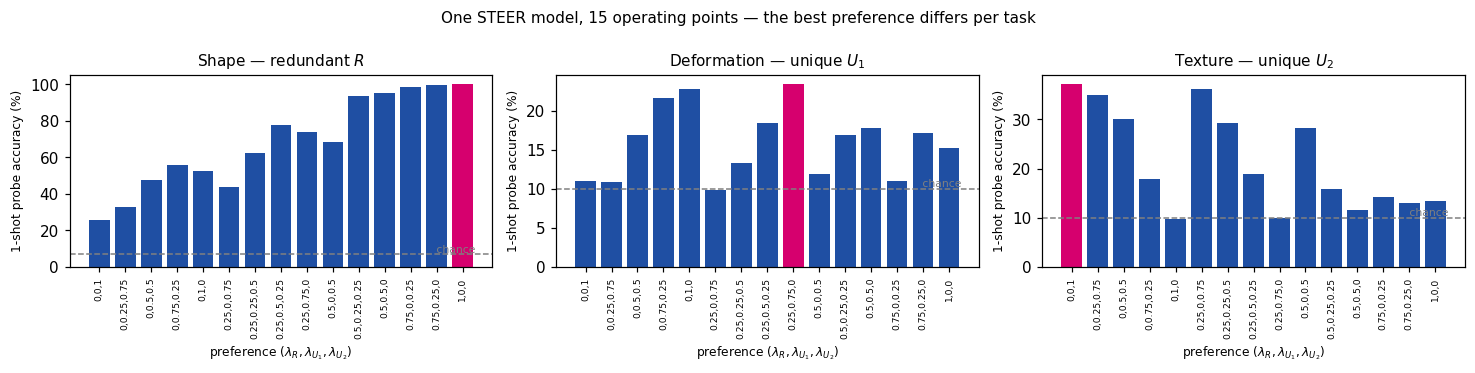

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
for ax, (name, key, n_cls) in zip(
        axes, (("Shape — redundant $R$", "share", n_R),
               ("Deformation — unique $U_1$", "unique1", n_U1),
               ("Texture — unique $U_2$", "unique2", n_U2))):
    v = [100 * x for x in curve[key]]
    best = int(np.argmax(v))
    ax.bar(range(len(v)), v,
           color=["#D6006E" if i == best else "#1f4fa3" for i in range(len(v))])
    ax.axhline(100 / n_cls, ls="--", c="grey", lw=1)
    ax.text(len(v) - 0.5, 100 / n_cls, " chance", va="bottom", ha="right",
            fontsize=7, color="grey")
    ax.set_xticks(range(len(prefs)))
    ax.set_xticklabels([f"{p[0]:g},{p[1]:g},{p[2]:g}" for p in prefs],
                       rotation=90, fontsize=6)
    ax.set_xlabel(r"preference $(\lambda_R, \lambda_{U_1}, \lambda_{U_2})$", fontsize=8)
    ax.set_ylabel("1-shot probe accuracy (%)", fontsize=8)
    ax.set_title(name, fontsize=10)
plt.suptitle("One STEER model, 15 operating points — the best preference differs per task",
             fontsize=10)
plt.tight_layout(); plt.show()

### The Pareto front — the paper figure

Plotted in (R, U₁, U₂), the preference family traces a front: no single operating point
is best on all three axes. Nothing is fitted or interpolated — the vertices are exactly the
non-dominated preferences above, and the surface only records which of them are neighbours.

This writes `pareto_front_3d.pdf` / `.png`, the figure used in the paper. There it carries
the mean over seeds 42–46 and the baseline points; here it is this single run, STEER
alone.

STEER: 15 points, 14 non-dominated
  best on $R$          -> point 14  [1.0, 0.1518, 0.1338]  lambda=(1,0,0)
  best on $U_1$        -> point 8  [0.738, 0.2341, 0.0987]  lambda=(0.25,0.75,0)
  best on $U_2$        -> point 0  [0.2581, 0.1101, 0.3721]  lambda=(0,0,1)
wrote pareto_front_3d.pdf and pareto_front_3d.png

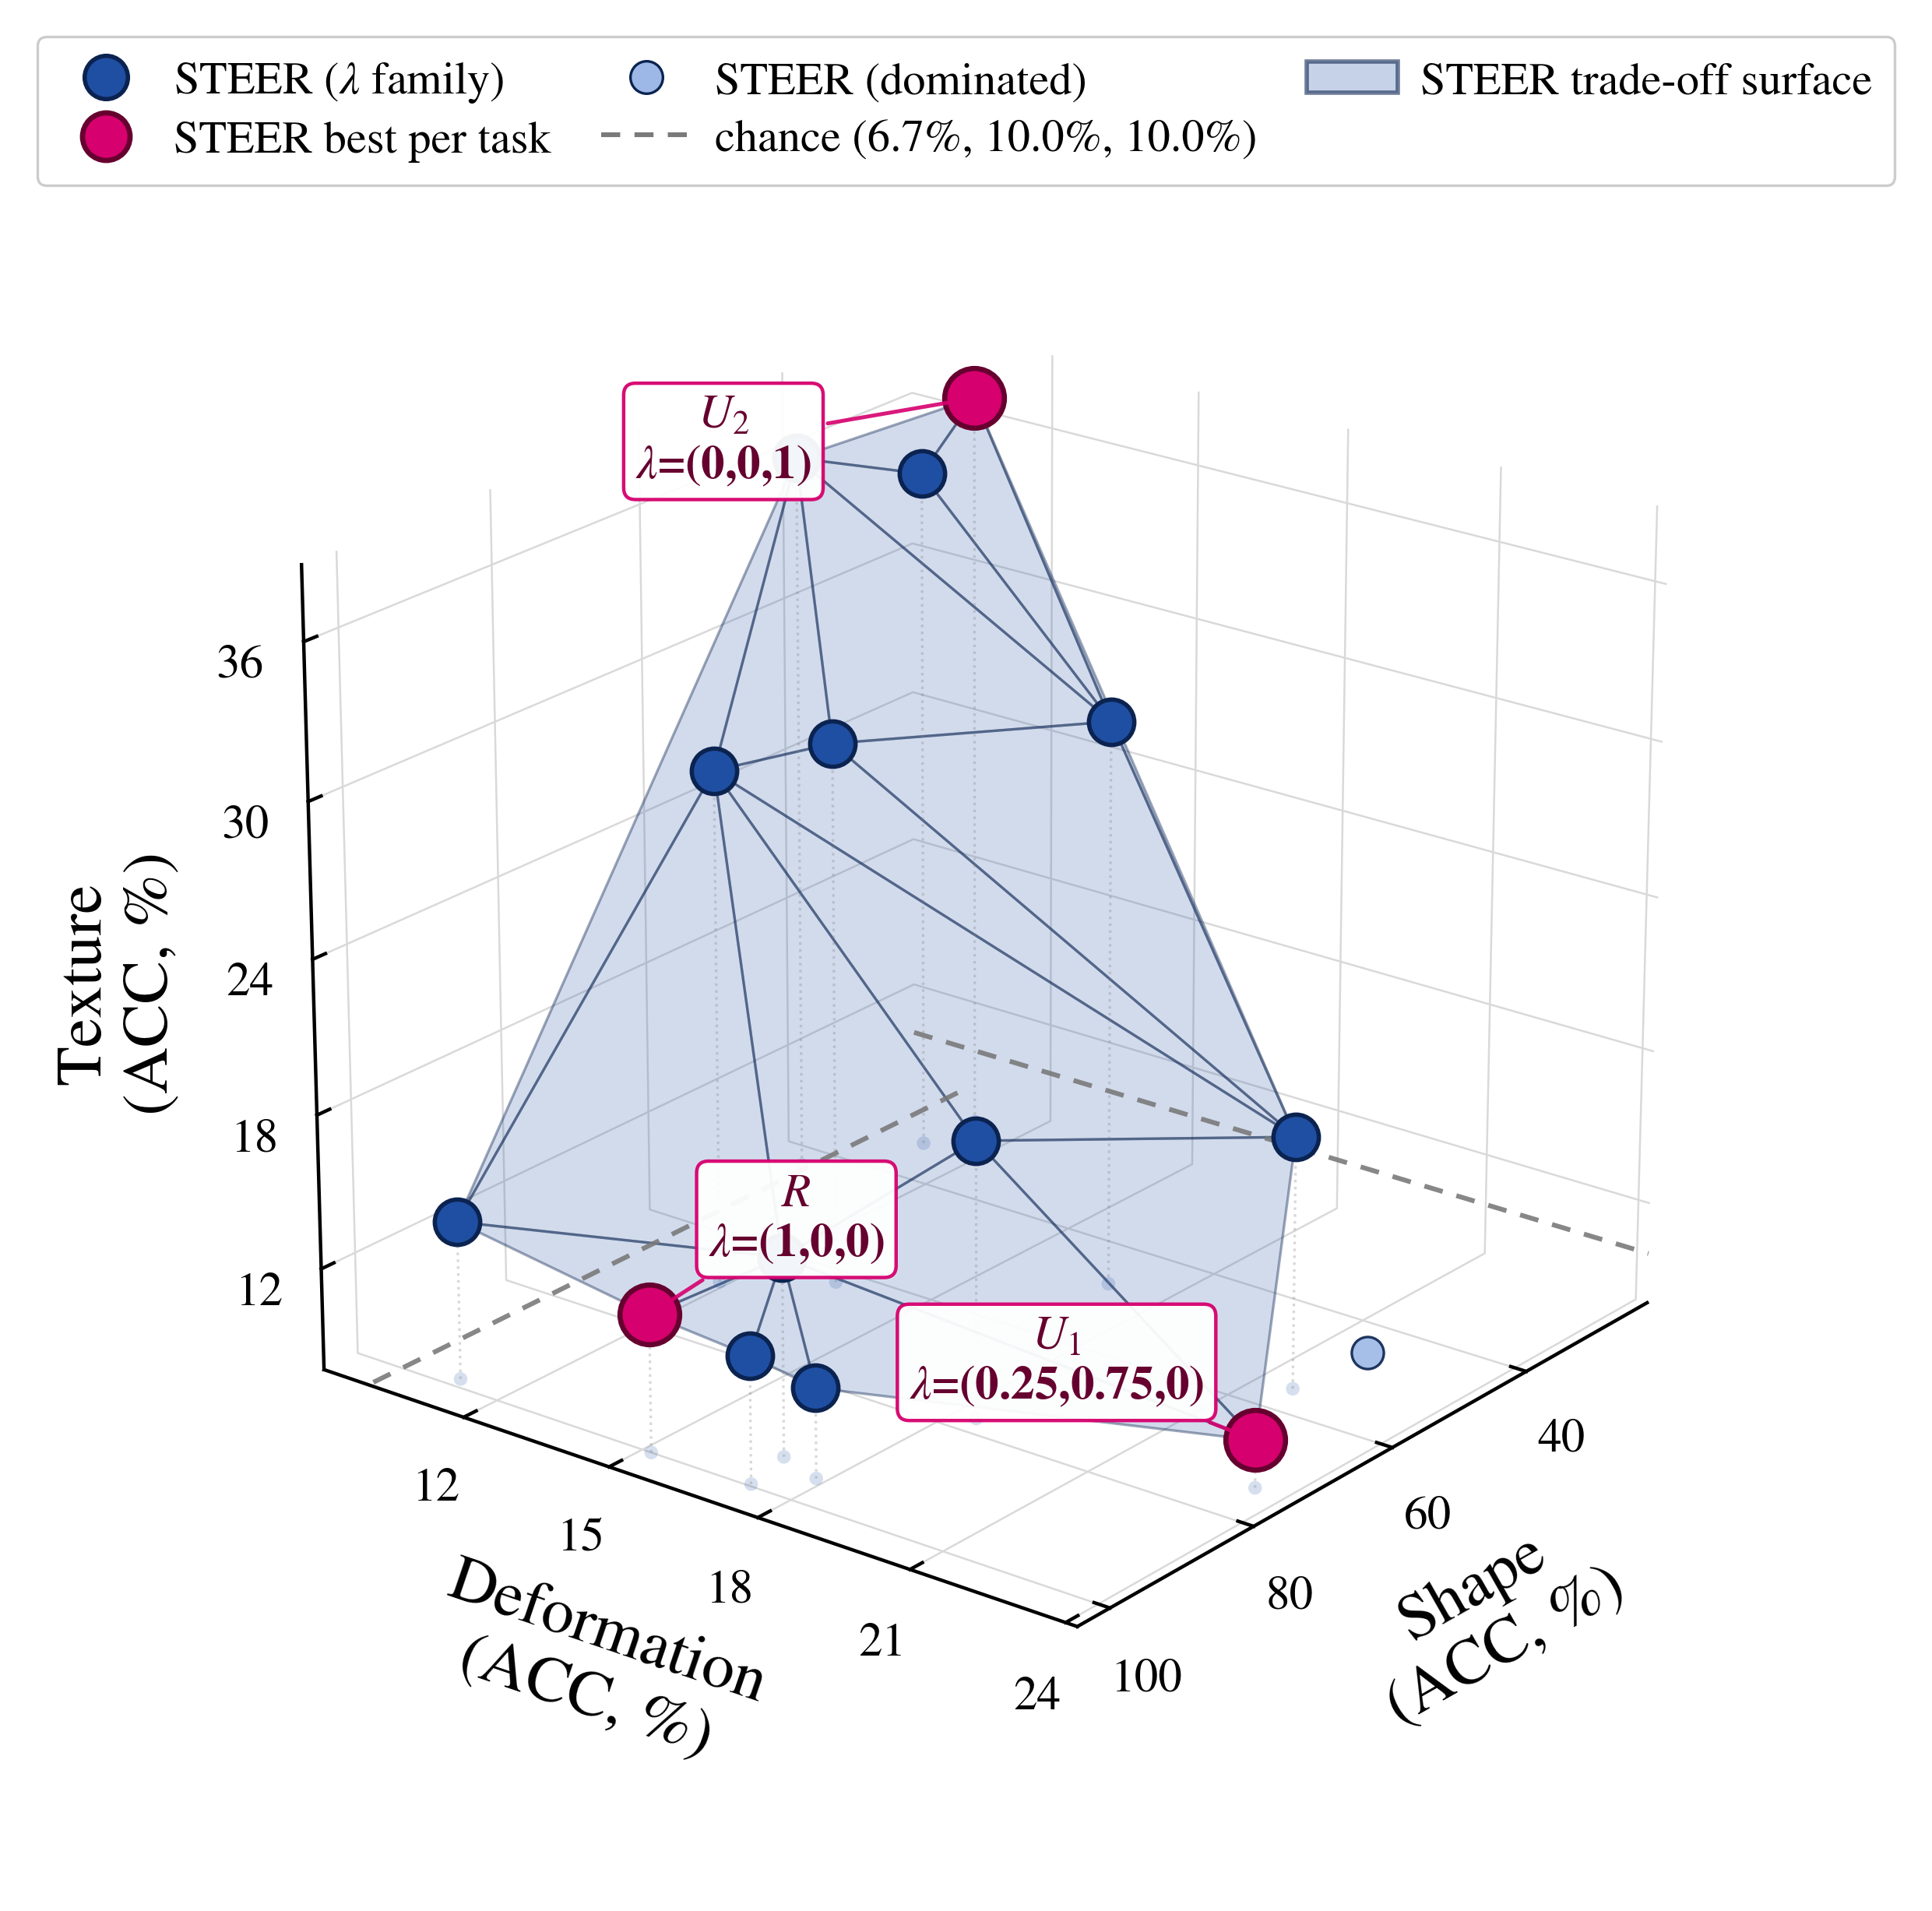

In [8]:
import pareto_ssl.plot_pareto_front_3d as pf
from IPython.display import Image as IPImage, display

pf.steer_lambdas = prefs          # annotate the per-task winners with their preference
pf.plot(
    steer=[[r, u1, u2] for r, u1, u2 in
           zip(curve["share"], curve["unique1"], curve["unique2"])],
    baselines={},
    out_stem="pareto_front_3d",
)
display(IPImage("pareto_front_3d.png", width=760))